# Earth-2 Weather Analytics Blueprint: Jupyter Notebook

This example notebook demonstrates the **notebook-based workflow** of the Earth-2 Weather Analytics Blueprint: connecting to the Data Federation Mesh (DFM), building and submitting a weather pipeline, and visualizing AI forecast results.

## What is the Data Federation Mesh (DFM)?

The [Data Federation Mesh (DFM)](https://github.com/NVIDIA/data-federation-mesh) is a programmable framework for orchestrating data processing across distributed *sites*. Each site is a group of services and resources in one location. DFM acts as "glue code as a service" as it coordinates where work runs and how data flows. It brings compute to the data by running pipeline steps close to where data lives to reduce latency, bandwidth, and cost, and helps keep data within desired security boundaries. Multiple sites form a *federation* and expose a single, coherent API so clients can submit pipelines without knowing the underlying topology.

In this blueprint, pipeline **operations** (e.g. `LoadGfsEra5Data`, `SfnoPrognostic`) are implemented by **adapters**  that use [NVIDIA Earth2Studio](https://github.com/NVIDIA/earth2studio) under the hood. You build a pipeline from these operations, submit it to the federation, and DFM runs it on the site and returns results.

## Prerequisites

Before running this notebook:

1. **Set up the Python environment**: from the repo root, run `./setup.sh`, then select the created environment (`.venv-notebook`) as the Jupyter kernel.
2. **Start the DFM site container**: in a separate terminal, run `./src/run_container.sh` from the repo root. The notebook connects to this site to execute pipelines.

See [Quickstart](docs/01_quickstart.md) for more details.

## 1. Imports and configuration

Import standard library, third-party, and blueprint/DFM modules. The federation API provides pipeline operations (`LoadGfsEra5Data`, `SfnoPrognostic`, `ConvertToUint8`, `RenderUint8ToImages`).

In [1]:
from base64 import b64decode
from datetime import datetime, timedelta, timezone
from io import BytesIO
from pathlib import Path

import matplotlib.cm as cm
import numpy as np
from IPython.display import Image as IPImage, display
from PIL import Image

from nv_dfm_core.api import ErrorToken, Pipeline, StopToken, Yield
from nv_dfm_core.session import JobStatus
from nv_dfm_core.targets.flare import FlareOptions

from federation.fed.api.dataloader import LoadGfsEra5Data
from federation.fed.api.sfno import SfnoPrognostic
from federation.fed.api.xarray import ConvertToUint8, RenderUint8ToImages
from federation.fed.runtime.homesite import get_session

The SFNO (Spherical Fourier Neural Operator) model requires a fixed set of atmospheric variables.

In [2]:
SFNO_VARIABLES = [
    "u10m", "v10m", "u100m", "v100m", "t2m", "sp", "msl", "tcwv",
    "u50", "u100", "u150", "u200", "u250", "u300", "u400", "u500",
    "u600", "u700", "u850", "u925", "u1000",
    "v50", "v100", "v150", "v200", "v250", "v300", "v400", "v500",
    "v600", "v700", "v850", "v925", "v1000",
    "z50", "z100", "z150", "z200", "z250", "z300", "z400", "z500",
    "z600", "z700", "z850", "z925", "z1000",
    "t50", "t100", "t150", "t200", "t250", "t300", "t400", "t500",
    "t600", "t700", "t850", "t925", "t1000",
    "q50", "q100", "q150", "q200", "q250", "q300", "q400", "q500",
    "q600", "q700", "q850", "q925", "q1000",
]

## 2. Connect to the federation

A **session** is your connection to the federation. It talks to the DFM and lets you prepare and run pipelines. In POC mode the site runs locally on the same machine. `get_session()` uses the blueprint’s preconfigured paths (Flare workspace and admin package) so the session finds that local site. Once connected, you use the session to submit pipelines and collect results.

In [3]:
DEFAULT_POC_FLARE_WORKSPACE = Path("./workspace/earth2_poc/")
DEFAULT_POC_JOB_WORKSPACE = Path("/tmp/job_workspace")
DEFAULT_POC_ADMIN_PACKAGE = Path("./workspace/earth2_poc/federation/prod_00/homesite@earth2.nvidia.com")
DEFAULT_POC_USER = "homesite@earth2.nvidia.com"

session = get_session(
    target="flare",
    user=DEFAULT_POC_USER,
    flare_workspace=DEFAULT_POC_FLARE_WORKSPACE,
    job_workspace=DEFAULT_POC_JOB_WORKSPACE,
    admin_package=DEFAULT_POC_ADMIN_PACKAGE
)
session.connect()
print("Connected to federation!")

Connected to federation!


## 3. Define and submit a pipeline

A DFM pipeline is a **graph of operations**. Each node is an operation, and data flows along the edges (e.g. the output of one step is the input of the next). Results are sent back to the client using `Yield(...)`.

This example pipeline uses four operations:

1. **LoadGfsEra5Data**: Load initial conditions (GFS/ERA5) for the given date and SFNO variables.
2. **SfnoPrognostic**: Run the SFNO model for `n_steps` forecast steps.
3. **ConvertToUint8**: Convert the dataset to uint8 for visualization.
4. **RenderUint8ToImages**: Render each timestep as a PNG texture. The final output is yielded so the notebook can display it.


In [4]:
def build_pipeline(site: str = "client1", n_steps: int = 12, date: str = None) -> Pipeline:
    if date is None:
        selection = {"time": (datetime.now(timezone.utc) - timedelta(days=3)).date().isoformat()}
    else:
        selection = {"time": date}
    
    with Pipeline() as pipeline:
        gfs_data = LoadGfsEra5Data(
            site=site,
            variables=SFNO_VARIABLES,
            selection=selection,
        )
        forecast = SfnoPrognostic(
            site=site,
            dataset=gfs_data,
            n_steps=n_steps,
            device="cuda",
        )
        uint8 = ConvertToUint8(
            site=site,
            data=forecast,
            time_dimension="time",
            xydims=["lon", "lat"],
            min_value=250,
            max_value=300,
        )
        images = RenderUint8ToImages(
            site=site,
            data=uint8,
            variable="t2m",
            xydims=["lon", "lat"],
            time_dimension="time",
            format="png",
        )
        Yield(value=images)

    return pipeline

**Prepare** validates the pipeline graph and binds it to the federation. **Execute** submits the job to the DFM. The site runs the pipeline and may send back multiple results. We use a callback to collect *yielded* results. The DFM also sends control tokens (`StopToken`, `ErrorToken`). We ignore those and keep only the actual data.

In [5]:
pipeline = build_pipeline()
prepared = session.prepare(pipeline)
print("Pipeline prepared!")

results = []

def collect_result(from_site, from_node, frame, target_place, data):
    """Collect yielded results; ignore control tokens (StopToken, ErrorToken)."""
    if not isinstance(data, (StopToken, ErrorToken)):
        results.append(data)

print("Submitting job...")
job = session.execute(
    prepared,
    input_params={},
    default_callback=collect_result,
    options=FlareOptions(task_timeout_s=900),
)
print(f"Job submitted: {job.job_id}")

Pipeline prepared!
Submitting job...
Job submitted: b61c57cb-2961-4db6-9fa5-d80eeeaa6e84


Wait for the job to finish. The first run may take longer while the DFM site downloads SFNO model weights.
If you encounter an error, rerun from the cell above (the one that submits the job) onward as it may be related to the download of the weights.

In [6]:
success = job.wait_until_finished(timeout=900)
status = job.get_status()
print(f"Job completed: {success}")
print(f"Job status: {status}")

# If job failed, there might be errors to check
if status != JobStatus.FINISHED:
    print(f"WARNING: Job did not finish successfully. Check local worker logs printed in the notebook/terminal")

Job completed: True
Job status: JobStatus.FINISHED


## 4. Visualize results

The yielded data is a `TextureFileList` of base64-encoded PNGs (one per timestep). Decode them, apply a colormap, and display as an animated GIF.

Number of images: 13


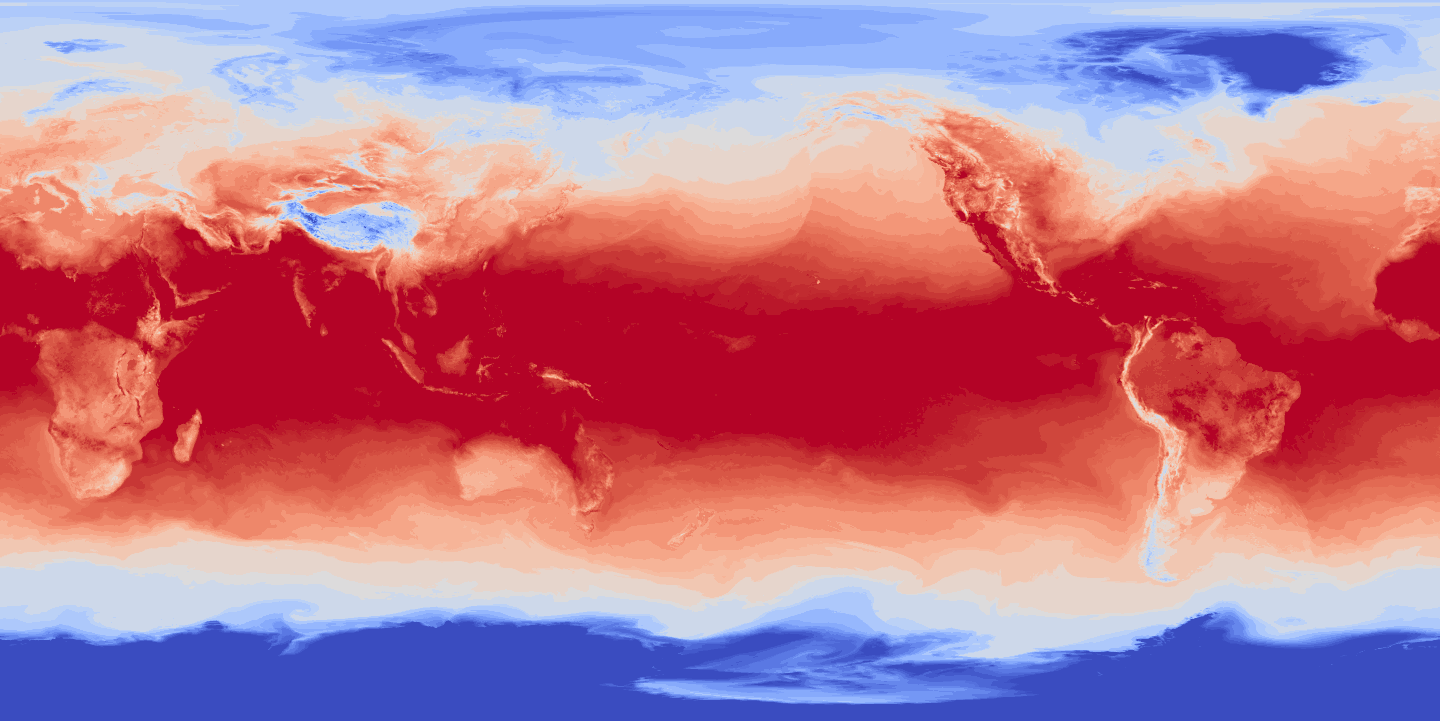

In [7]:
images = results[0]
num_images = len(images.texture_files)
print(f"Number of images: {num_images}")

# Decode base64 PNGs and apply colormap
frames = []
for texture_file in images.texture_files:
    img_data = b64decode(texture_file.base64_image_data)
    img = Image.open(BytesIO(img_data)).convert("L")
    img_array = np.array(img)
    colored = cm.coolwarm(img_array / 255.0)
    colored_uint8 = (colored * 255).astype(np.uint8)
    frames.append(Image.fromarray(colored_uint8))

# Save as animated GIF (500 ms per frame, loop forever)
gif_path = Path("outputs/forecast.gif")
gif_path.parent.mkdir(parents=True, exist_ok=True)
frames[0].save(gif_path, save_all=True, append_images=frames[1:], loop=0, duration=500)
display(IPImage(filename=gif_path))

Close the session when you're done. For more on DFM concepts, additional documentation, and tutorials, refer to the
[Data Federation Mesh](https://github.com/NVIDIA/data-federation-mesh) repository.

In [8]:
session.close()